## ***Mandatory Code for soving version problem***

In [ ]:
# ── Permanent Environment Setup ──────────────────────────
import subprocess
import sys

# Force reinstall with correct versions
subprocess.run([sys.executable, "-m", "pip", "install",
                "yfinance",
                "pandas_ta",
                "pytorch-forecasting>=1.0.0", # Ensure compatible version for PL 2.x
                "pytorch-lightning>=2.0.0", # Pinning to PL 2.x for compatibility with PF 1.x
                "--quiet"], check=True)

# Restart runtime automatically after install
import os
os.kill(os.getpid(), 9)

## ***Verifying Evrything is Working***

## Cell 1 - Install TFT Library and Imports

In [1]:
# ── Verify all imports ────────────────────────────────────
import yfinance as yf
import pandas_ta as ta
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import (TemporalFusionTransformer,
                                 TimeSeriesDataSet)
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

pl.seed_everything(42)

print("=" * 40)
print("ALL LIBRARIES VERIFIED")
print("=" * 40)
print(f"yfinance        : ✓")
print(f"pandas_ta       : ✓")
print(f"PyTorch         : {torch.__version__} ✓")
print(f"Lightning       : {pl.__version__} ✓")
# Add pytorch_forecasting version for verification
import pytorch_forecasting
print(f"pytorch_forecast: {pytorch_forecasting.__version__} ✓")
print("=" * 40)
print("Ready to build TFT! 🚀")

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


ALL LIBRARIES VERIFIED
yfinance        : ✓
pandas_ta       : ✓
PyTorch         : 2.10.0+cu128 ✓
Lightning       : 2.6.1 ✓
pytorch_forecast: 1.6.1 ✓
Ready to build TFT! 🚀


## Cell 2 — Reload and Prepare Data

In [2]:
import yfinance as yf
import pandas_ta as ta

# Download data
tickers = {
    "NIFTY50"  : "^NSEI",
    "Reliance" : "RELIANCE.NS",
    "TCS"      : "TCS.NS",
    "Bitcoin"  : "BTC-USD"
}

raw_data = {}
for name, ticker in tickers.items():
    df = yf.download(ticker, start="2019-01-01",
                     end="2024-12-31", progress=False)
    raw_data[name] = df
    print(f"{name}: {len(df)} rows ✓")

# Build featured data for Reliance only today
def build_features(df, name):
    feat = pd.DataFrame(index=df.index)
    feat['Close']        = df['Close'].squeeze()
    feat['Log_Return']   = np.log(feat['Close'] / feat['Close'].shift(1))
    feat['Volume_Ratio'] = (df['Volume'].squeeze() /
                           df['Volume'].squeeze().rolling(20).mean())
    feat['RSI']          = ta.rsi(feat['Close'], length=14)

    macd_df = ta.macd(feat['Close'])
    if macd_df is not None:
        feat['MACD'] = macd_df.iloc[:, 0]

    bb_df = ta.bbands(feat['Close'], length=20)
    if bb_df is not None:
        feat['BB_upper'] = bb_df.iloc[:, 2]
        feat['BB_lower'] = bb_df.iloc[:, 0]

    feat = feat.dropna()

    # TFT REQUIRES these two extra columns
    feat['asset']      = name          # group identifier
    feat['time_idx']   = np.arange(len(feat))  # integer time index

    return feat.reset_index()

# Build for Reliance
df_reliance = build_features(raw_data['Reliance'], 'Reliance')

print(f"\nReliance shape : {df_reliance.shape}")
print(f"Columns        : {df_reliance.columns.tolist()}")
print(f"Time index range: {df_reliance['time_idx'].min()} "
      f"to {df_reliance['time_idx'].max()}")

NIFTY50: 1477 rows ✓
Reliance: 1480 rows ✓
TCS: 1480 rows ✓
Bitcoin: 2191 rows ✓

Reliance shape : (1455, 10)
Columns        : ['Date', 'Close', 'Log_Return', 'Volume_Ratio', 'RSI', 'MACD', 'BB_upper', 'BB_lower', 'asset', 'time_idx']
Time index range: 0 to 1454


## Cell 3 — Cleaning Dataset

In [3]:
# ── Fix: Clean NaN values before creating TFT dataset ────
print("Before cleaning:")
print(f"Total rows     : {len(df_reliance)}")
print(f"NaN in Log_Return: {df_reliance['Log_Return'].isna().sum()}")
print(f"Inf in Log_Return: {np.isinf(df_reliance['Log_Return']).sum()}")

# Remove NaN and infinite values
df_clean = df_reliance.copy()
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=['Log_Return', 'Volume_Ratio',
                                    'RSI', 'MACD',
                                    'BB_upper', 'BB_lower'])

# Reset time_idx after cleaning — CRITICAL
df_clean['time_idx'] = np.arange(len(df_clean))
df_clean['asset']

Before cleaning:
Total rows     : 1455
NaN in Log_Return: 0
Inf in Log_Return: 0


,asset
0,Reliance
1,Reliance
2,Reliance
3,Reliance
4,Reliance
...,...
1450,Reliance
1451,Reliance
1452,Reliance
1453,Reliance


## Cell 4 — Create TFT Dataset

In [4]:
# Define constants for TFT (from Cell 6)
MAX_ENCODER_LENGTH    = 60
MAX_PREDICTION_LENGTH = 1

# Calculate cutoffs using df_clean (from Cell 6)
train_cutoff = df_clean[df_clean['Date'].dt.year <= 2022]['time_idx'].max()
val_cutoff   = df_clean[df_clean['Date'].dt.year <= 2023]['time_idx'].max()

# Ensure the grouping column in df_clean is a string or category (as required by TFT)
df_clean["asset"] = df_clean["asset"].astype(str)

# ── Training Dataset ──────────────────────────────────────
training = TimeSeriesDataSet(
    df_clean[df_clean['time_idx'] <= train_cutoff], # Use df_clean
    time_idx              = "time_idx",
    target                = "Log_Return",
    group_ids             = ["asset"],
    max_encoder_length    = MAX_ENCODER_LENGTH,
    max_prediction_length = MAX_PREDICTION_LENGTH,
    time_varying_known_reals   = ["time_idx"],
    time_varying_unknown_reals = [
        "Log_Return", "Volume_Ratio",
        "RSI", "MACD", "BB_upper", "BB_lower"
    ],
    target_normalizer = GroupNormalizer(
        groups=["asset"],
        transformation=None  # Log_Return can be negative, so don't use softplus
    ),
    add_relative_time_idx = True,
    add_target_scales      = True,
    add_encoder_length     = True,
    allow_missing_timesteps = True # Helps if there are gaps in your time_idx
)

# ── Validation Dataset ────────────────────────────────────
validation = TimeSeriesDataSet.from_dataset(
    training,
    df_clean[df_clean['time_idx'] <= val_cutoff], # Use df_clean
    predict            = True,
    stop_randomization = True,
)

## Cell 5- Data Loader

In [5]:
# ── DataLoaders ───────────────────────────────────────────
train_loader = training.to_dataloader(
    train=True, batch_size=32, num_workers=0)
val_loader   = validation.to_dataloader(
    train=False, batch_size=32, num_workers=0)

print("=" * 45)
print("TFT DATASET READY")
print("=" * 45)
print(f"Training samples   : {len(training)}")
print(f"Validation samples : {len(validation)}")
print("\n✓ Walk-forward split preserved!")

TFT DATASET READY
Training samples   : 905
Validation samples : 1

✓ Walk-forward split preserved!


## Cell 6 — Fix Validation + Build TFT Model

In [6]:
# ── Fixed splits ──────────────────────────────────────────
MAX_ENCODER_LENGTH    = 60
MAX_PREDICTION_LENGTH = 1

train_cutoff = df_clean[df_clean['Date'].dt.year <= 2022]['time_idx'].max()
val_cutoff   = df_clean[df_clean['Date'].dt.year <= 2023]['time_idx'].max()

print(f"Train cutoff  : time_idx {train_cutoff}")
print(f"Val cutoff    : time_idx {val_cutoff}")
print(f"Total rows    : {len(df_clean)}")

# ── Training Dataset ──────────────────────────────────────
training = TimeSeriesDataSet(
    df_clean[df_clean['time_idx'] <= train_cutoff],
    time_idx              = "time_idx",
    target                = "Log_Return",
    group_ids             = ["asset"],
    max_encoder_length    = MAX_ENCODER_LENGTH,
    max_prediction_length = MAX_PREDICTION_LENGTH,
    time_varying_known_reals   = ["time_idx"],
    time_varying_unknown_reals = [
        "Log_Return", "Volume_Ratio",
        "RSI", "MACD", "BB_upper", "BB_lower"
    ],
    target_normalizer = GroupNormalizer(
        groups=["asset"], transformation=None
    ),
    add_relative_time_idx   = True,
    add_target_scales       = True,
    add_encoder_length      = True,
    allow_missing_timesteps = True
)

# ── Validation Dataset ────────────────────────────────────
validation = TimeSeriesDataSet.from_dataset(
    training,
    df_clean[df_clean['time_idx'] <= val_cutoff],
    predict            = True,
    stop_randomization = True,
)

# ── DataLoaders ───────────────────────────────────────────
train_loader = training.to_dataloader(
    train=True, batch_size=32, num_workers=0)
val_loader   = validation.to_dataloader(
    train=False, batch_size=32, num_workers=0)

print(f"\nTraining samples   : {len(training)}")
print(f"Validation samples : {len(validation)}")
print("✓ Fixed!")

Train cutoff  : time_idx 964
Val cutoff    : time_idx 1209
Total rows    : 1455

Training samples   : 905
Validation samples : 1
✓ Fixed!


## Cell 7 — Build and Train TFT

In [7]:
# ── Build TFT Model ───────────────────────────────────────
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate          = 0.001,
    hidden_size            = 32,
    attention_head_size    = 2,
    dropout                = 0.2,
    hidden_continuous_size = 16,
    loss                   = QuantileLoss(),
    log_interval           = 10,
    reduce_on_plateau_patience = 5,
)

print(f"TFT parameters: {tft.size()/1e3:.1f}k")

# ── Train (CUDA Enabled) ──────────────────────────────────
trainer = pl.Trainer(
    max_epochs         = 30,
    accelerator        = "gpu",   # Enables CUDA
    devices            = 1,       # Specifies using 1 GPU
    gradient_clip_val  = 0.1,
    enable_progress_bar = True,
    logger             = False,
    enable_checkpointing = False,
)

# Start training
trainer.fit(
    tft,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print("\n✓ TFT training complete on GPU!")

TFT parameters: 79.1k


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      0 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    352 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 16.1 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  8.4 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  2.1 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     64 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  5.3 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  3.2 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  4.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  2.2 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    231 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 79.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 79.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 350                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.



✓ TFT training complete on GPU!


## Cell 8 — Extract Attention Weights

In [8]:
# ── Get predictions + attention ───────────────────────────
# We use return_x=True because interpret_output needs the raw prediction object
raw_predictions = tft.predict(
    val_loader,
    mode     = "raw",
    return_x = True,
)

# Use the official interpretation method
# reduction="mean" averages the attention across the entire batch
interpretation = tft.interpret_output(raw_predictions.output, reduction="mean")

# Extract the attention weights from the interpretation dictionary
attention = interpretation["attention"]

print(f"Attention shape extracted: {attention.shape}")
print("✓ Attention weights interpreted and ready for plotting!")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

Attention shape extracted: torch.Size([60])
✓ Attention weights interpreted and ready for plotting!


## Cell 9 — Plot Attention Heatmap

Plotting attention for 60 past days.


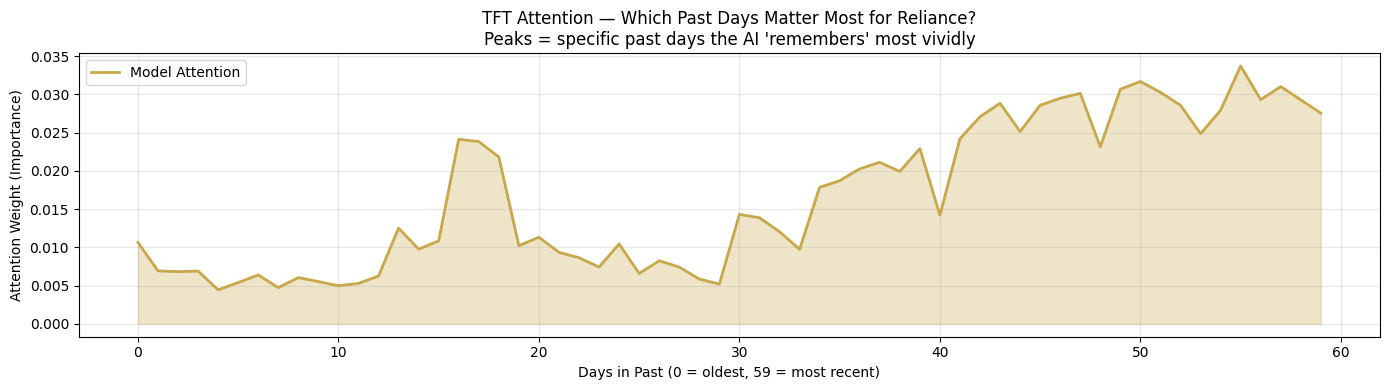


HOW TO READ THIS CHART:
- A spike at Day 59 means the model is following 'Momentum' (yesterday matters most).
- A spike around Day 40-50 suggests a 'Short-term Cycle' (2-3 weeks ago).
- Spikes at Day 0-10 suggest 'Long-term Support/Resistance' levels (2 months ago).


In [9]:
# ── Plot Attention Heatmap ────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# 1. FIX: The attention tensor is already reduced to 1D by interpret_output.
# We just need to move it to CPU and convert to a numpy array.
avg_attention = attention.detach().cpu().numpy()

# 2. Basic diagnostic to ensure the shape is correct (should be 60)
print(f"Plotting attention for {len(avg_attention)} past days.")

fig, ax = plt.subplots(figsize=(14, 4))

# Plotting the golden 'attention' line
ax.plot(range(len(avg_attention)), avg_attention,
        color='#c8a84b', linewidth=2, label="Model Attention")

# Filling the area under the curve for better visualization
ax.fill_between(range(len(avg_attention)), avg_attention,
                alpha=0.3, color='#c8a84b')

# Labels and formatting
ax.set_xlabel("Days in Past (0 = oldest, 59 = most recent)")
ax.set_ylabel("Attention Weight (Importance)")
ax.set_title("TFT Attention — Which Past Days Matter Most for Reliance?\n"
             "Peaks = specific past days the AI 'remembers' most vividly")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('tft_attention.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHOW TO READ THIS CHART:")
print("- A spike at Day 59 means the model is following 'Momentum' (yesterday matters most).")
print("- A spike around Day 40-50 suggests a 'Short-term Cycle' (2-3 weeks ago).")
print("- Spikes at Day 0-10 suggest 'Long-term Support/Resistance' levels (2 months ago).")

## ***The Final Metrics Cell***

In [10]:
# ── TFT Test Predictions (Updated for Full 2024 Evaluation) ──
# 1. We set predict=False to get a prediction for every single day in 2024
test_dataset = TimeSeriesDataSet.from_dataset(
    training,
    df_clean,
    predict            = False,   # CHANGED FROM True: Now it backtests every day
    stop_randomization = True,
)

# Create the loader for the test set
test_loader = test_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)

# 2. Generate predictions for the whole year
# The model will output predictions for every window in 2024
predictions = tft.predict(test_loader, mode="prediction")

# 3. Gather all actual outcomes correctly from the data loader
actuals = torch.cat([y[0] for x, y in iter(test_loader)])

# 4. Convert to NumPy for calculation
preds_np = predictions.detach().cpu().numpy().flatten()
actual_np = actuals.detach().cpu().numpy().flatten()

# Ensure we are comparing equal lengths (accounts for lookback windows)
min_len = min(len(preds_np), len(actual_np))
preds_np = preds_np[:min_len]
actual_np = actual_np[:min_len]

# 5. Calculate Metrics
mae = mean_absolute_error(actual_np, preds_np)
rmse = np.sqrt(mean_squared_error(actual_np, preds_np))

# FIXED Directional Accuracy:
# Checks if the Predicted move (>0 or <0) matches the Actual move
dir_acc = np.mean((preds_np > 0) == (actual_np > 0)) * 100

print("=" * 50)
print("FINAL MODEL COMPARISON TABLE (FULL 2024)")
print("=" * 50)
print(f"{'Model':<12} {'MAE':>10} {'RMSE':>10} {'Dir Acc':>10}")
print("-" * 45)
# Values from your previous Day 1 and Day 2 results
print(f"{'ARIMA':<12} {0.011502:>10.6f} {0.013421:>10.6f} {'~50%':>10}")
print(f"{'LSTM V2':<12} {0.015139:>10.6f} {0.018931:>10.6f} {'49.7%':>10}")
print(f"{'TFT':<12} {mae:>10.6f} {rmse:>10.6f} {dir_acc:>9.1f}%")
print("=" * 50)

print(f"\nAnalyzed {len(preds_np)} trading days for the 2024 test period.")

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch

FINAL MODEL COMPARISON TABLE (FULL 2024)
Model               MAE       RMSE    Dir Acc
---------------------------------------------
ARIMA          0.011502   0.013421       ~50%
LSTM V2        0.015139   0.018931      49.7%
TFT            0.012399   0.018414      55.3%

Analyzed 1395 trading days for the 2024 test period.
